<a href="https://colab.research.google.com/github/bavyasudhir18/machine-learning-codes/blob/main/spoofing1_62_9%25.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"cnn11c19","key":"b1540309a40268a04eff7a3d20c0c9bb"}'}

In [4]:
!pip install kaggle

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Download dataset
!kaggle datasets download -d tapakah68/anti-spoofing

# Unzip
!unzip anti-spoofing.zip

Dataset URL: https://www.kaggle.com/datasets/tapakah68/anti-spoofing
License(s): Attribution-NonCommercial-NoDerivatives 4.0 International (CC BY-NC-ND 4.0)
anti-spoofing.zip: Skipping, found more recently modified local copy (use --force to force download)
Archive:  anti-spoofing.zip
replace anti-spoofing.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: A
  inflating: anti-spoofing.csv       
  inflating: cut-out printouts/0001e96803--6228928cb608822f9f53589e.mp4  
  inflating: cut-out printouts/0001e96803--62294efac72a824e5bb369f3.mp4  
  inflating: cut-out printouts/0001e96803--623955e76e1ee5175569a12b.mp4  
  inflating: cut-out printouts/0001e96803--6239bb2420237d576aade0ea.mp4  
  inflating: cut-out printouts/0001e96803--6239cf6720237d576aafbe45.mp4  
  inflating: cut-out printouts/0001e96803--624508e961974a65884d9fd3.mp4  
  inflating: cut-out printouts/0001e96803--62457bc94ff454214e8af551.mp4  
  inflating: cut-out printouts/0001e96803--625473b64949293a58c89e41.mp4  
  inflating: cut-

In [5]:
import os

base_path = "/content"

for root, dirs, files in os.walk(base_path):
    print(root)
    break

/content


In [6]:
for root, dirs, files in os.walk("/content"):
    print(root)

/content
/content/.config
/content/.config/configurations
/content/.config/logs
/content/.config/logs/2026.03.30
/content/live_video
/content/cut-out printouts
/content/replay
/content/printouts
/content/live_selfie
/content/sample_data


In [7]:
import os
import shutil
import random

source_path = "/content/anti-spoofing"   # change if needed
dest_path = "/content/dataset"

classes = {
    "real": ["live"],   # modify folder names
    "fake": ["spoof", "print", "replay"]
}

for split in ["train", "test"]:
    for cls in ["real", "fake"]:
        os.makedirs(f"{dest_path}/{split}/{cls}", exist_ok=True)

In [8]:
def split_data(source_folders, label):
    all_files = []

    for folder in source_folders:
        folder_path = os.path.join(source_path, folder)
        for file in os.listdir(folder_path):
            all_files.append(os.path.join(folder_path, file))

    random.shuffle(all_files)

    split = int(0.8 * len(all_files))
    train_files = all_files[:split]
    test_files = all_files[split:]

    for f in train_files:
        shutil.copy(f, f"{dest_path}/train/{label}/")

    for f in test_files:
        shutil.copy(f, f"{dest_path}/test/{label}/")

In [10]:
import os

base_path = "/content"

for root, dirs, files in os.walk("/content"):
    print("📁", root)
    print("Subfolders:", dirs)
    print("Files:", files[:5])
    print("-"*50)
    break

📁 /content
Subfolders: ['.config', 'live_video', 'cut-out printouts', 'replay', 'printouts', 'dataset', 'live_selfie', 'sample_data']
Files: ['kaggle.json', 'kaggle (1).json', 'anti-spoofing.csv', 'anti-spoofing.zip']
--------------------------------------------------


In [11]:
source_path = "/content"

real_folders = ["live_video", "live_selfie"]
fake_folders = ["replay", "printouts", "cut-out printouts"]

dest_path = "/content/dataset"

In [12]:
import os

for split in ["train", "test"]:
    for cls in ["real", "fake"]:
        os.makedirs(f"{dest_path}/{split}/{cls}", exist_ok=True)

In [13]:
import shutil
import random

def split_data(folder_list, label):
    all_files = []

    for folder in folder_list:
        folder_path = os.path.join(source_path, folder)

        for file in os.listdir(folder_path):
            full_path = os.path.join(folder_path, file)

            if os.path.isfile(full_path):
                all_files.append(full_path)

    random.shuffle(all_files)

    # ⚡ LIMIT DATA (VERY IMPORTANT for Colab)
    all_files = all_files[:2000]

    split_index = int(0.8 * len(all_files))

    train_files = all_files[:split_index]
    test_files = all_files[split_index:]

    for f in train_files:
        shutil.copy(f, f"{dest_path}/train/{label}/")

    for f in test_files:
        shutil.copy(f, f"{dest_path}/test/{label}/")

In [14]:
split_data(real_folders, "real")
split_data(fake_folders, "fake")

In [15]:
print("Train REAL:", len(os.listdir("/content/dataset/train/real")))
print("Train FAKE:", len(os.listdir("/content/dataset/train/fake")))

Train REAL: 14
Train FAKE: 14


In [16]:
print(os.listdir("/content/live_video")[:5])

['0001e96803--62457bc94ff454214e8af551__Infinix note 11.mp4', '0001e96803--625473b64949293a58c89e41__Oppo a5s.mp4', '0001e96803--62663cf6d21d14509973bcb4__Poco x3.mp4', '0001e96803--6239cf6720237d576aafbe45__Samsung Galaxy a22.mp4', '0001e96803--6239bb2420237d576aade0ea__Moto G30.mp4']


In [17]:
import cv2
import os
import random

source_path = "/content"

real_folders = ["live_video", "live_selfie"]
fake_folders = ["replay", "printouts", "cut-out printouts"]

dest_path = "/content/dataset"

# Create folders
for split in ["train", "test"]:
    for cls in ["real", "fake"]:
        os.makedirs(f"{dest_path}/{split}/{cls}", exist_ok=True)


def extract_and_split(folder_list, label):
    video_files = []

    # Collect all videos
    for folder in folder_list:
        folder_path = os.path.join(source_path, folder)

        for file in os.listdir(folder_path):
            if file.endswith(".mp4"):
                video_files.append(os.path.join(folder_path, file))

    random.shuffle(video_files)

    # ⚡ LIMIT for Colab (IMPORTANT)
    video_files = video_files[:100]

    split_index = int(0.8 * len(video_files))

    train_videos = video_files[:split_index]
    test_videos = video_files[split_index:]

    def process_videos(video_list, split):
        for vid in video_list:
            cap = cv2.VideoCapture(vid)
            count = 0

            while True:
                ret, frame = cap.read()
                if not ret:
                    break

                # Take every 10th frame
                if count % 10 == 0:
                    filename = f"{split}_{label}_{os.path.basename(vid)}_{count}.jpg"
                    save_path = f"{dest_path}/{split}/{label}/{filename}"

                    cv2.imwrite(save_path, frame)

                count += 1

            cap.release()

    process_videos(train_videos, "train")
    process_videos(test_videos, "test")


# Run
extract_and_split(real_folders, "real")
extract_and_split(fake_folders, "fake")

In [18]:
import os

print("Train REAL:", len(os.listdir("/content/dataset/train/real")))
print("Train FAKE:", len(os.listdir("/content/dataset/train/fake")))
print("Test REAL:", len(os.listdir("/content/dataset/test/real")))
print("Test FAKE:", len(os.listdir("/content/dataset/test/fake")))

Train REAL: 240
Train FAKE: 472
Test REAL: 78
Test FAKE: 170


In [19]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
])

train_data = datasets.ImageFolder("/content/dataset/train", transform=transform)
test_data = datasets.ImageFolder("/content/dataset/test", transform=transform)

train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
test_loader = DataLoader(test_data, batch_size=32)

print("Classes:", train_data.classes)

Classes: ['fake', 'real']


In [20]:
import torch
import torch.nn as nn
import torchvision.models as models

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = models.resnet18(pretrained=True)

# Modify last layer
model.fc = nn.Linear(model.fc.in_features, 2)

model = model.to(device)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 171MB/s]


In [21]:
import torch
import torch.nn as nn
import torchvision.models as models

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = models.resnet18(pretrained=True)

# Modify last layer
model.fc = nn.Linear(model.fc.in_features, 2)

model = model.to(device)

In [22]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)

for epoch in range(5):
    model.train()
    running_loss = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {running_loss:.4f}")

Epoch 1, Loss: 4.0487
Epoch 2, Loss: 0.0735
Epoch 3, Loss: 0.0548
Epoch 4, Loss: 0.0193
Epoch 5, Loss: 0.0129


In [23]:
correct = 0
total = 0

model.eval()

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (preds == labels).sum().item()

print("Accuracy:", correct / total)

Accuracy: 0.6276150627615062


In [25]:
import os

real_path = "/content/dataset/test/real"

files = os.listdir(real_path)
print(files[:5])

['test_real_0001e96803--6228928cb608822f9f53589e__Xiaomi redmi note 9 pro.mp4_220.jpg', 'test_real_0001e96803--6228928cb608822f9f53589e__Xiaomi redmi note 9 pro.mp4_100.jpg', 'test_real_0001e96803--623955e76e1ee5175569a12b__HONOR 10I .mp4_140.jpg', 'test_real_0001e96803--623955e76e1ee5175569a12b__HONOR 10I .mp4_230.jpg', 'test_real_0001e96803--6228928cb608822f9f53589e__Xiaomi redmi note 9 pro.mp4_150.jpg']


In [26]:
from PIL import Image
import os
import torch

real_path = "/content/dataset/test/real"
files = os.listdir(real_path)

# Pick first image
img_path = os.path.join(real_path, files[0])

print("Testing image:", img_path)

img = Image.open(img_path).convert("RGB")
img = transform(img).unsqueeze(0).to(device)

model.eval()
output = model(img)

_, pred = torch.max(output, 1)

print("Prediction:", "REAL" if pred.item() == 1 else "FAKE")

Testing image: /content/dataset/test/real/test_real_0001e96803--6228928cb608822f9f53589e__Xiaomi redmi note 9 pro.mp4_220.jpg
Prediction: FAKE


In [27]:
for i in range(5):
    img_path = os.path.join(real_path, files[i])

    img = Image.open(img_path).convert("RGB")
    img = transform(img).unsqueeze(0).to(device)

    output = model(img)
    _, pred = torch.max(output, 1)

    print(files[i], "→", "REAL" if pred.item() == 1 else "FAKE")

test_real_0001e96803--6228928cb608822f9f53589e__Xiaomi redmi note 9 pro.mp4_220.jpg → FAKE
test_real_0001e96803--6228928cb608822f9f53589e__Xiaomi redmi note 9 pro.mp4_100.jpg → FAKE
test_real_0001e96803--623955e76e1ee5175569a12b__HONOR 10I .mp4_140.jpg → FAKE
test_real_0001e96803--623955e76e1ee5175569a12b__HONOR 10I .mp4_230.jpg → REAL
test_real_0001e96803--6228928cb608822f9f53589e__Xiaomi redmi note 9 pro.mp4_150.jpg → FAKE


In [28]:
import os

print("Train REAL:", len(os.listdir("/content/dataset/train/real")))
print("Train FAKE:", len(os.listdir("/content/dataset/train/fake")))

Train REAL: 240
Train FAKE: 472


In [29]:
import torch
import torch.nn as nn

real_count = 240
fake_count = 472

weights = torch.tensor([1.0/fake_count, 1.0/real_count]).to(device)

criterion = nn.CrossEntropyLoss(weight=weights)

In [30]:
from torchvision import transforms

transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.5, contrast=0.5),
    transforms.RandomAffine(degrees=0, translate=(0.1,0.1)),
    transforms.ToTensor(),
])

In [31]:
for epoch in range(12):
    model.train()
    correct = 0
    total = 0
    running_loss = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        _, preds = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (preds == labels).sum().item()

    print(f"Epoch {epoch+1} | Loss: {running_loss:.2f} | Train Acc: {correct/total:.2f}")

Epoch 1 | Loss: 0.02 | Train Acc: 1.00
Epoch 2 | Loss: 0.02 | Train Acc: 1.00
Epoch 3 | Loss: 0.01 | Train Acc: 1.00
Epoch 4 | Loss: 0.01 | Train Acc: 1.00
Epoch 5 | Loss: 0.01 | Train Acc: 1.00
Epoch 6 | Loss: 0.01 | Train Acc: 1.00
Epoch 7 | Loss: 0.01 | Train Acc: 1.00
Epoch 8 | Loss: 0.01 | Train Acc: 1.00
Epoch 9 | Loss: 0.00 | Train Acc: 1.00
Epoch 10 | Loss: 0.01 | Train Acc: 1.00
Epoch 11 | Loss: 0.00 | Train Acc: 1.00
Epoch 12 | Loss: 0.01 | Train Acc: 1.00


In [32]:
from sklearn.metrics import classification_report
import torch

all_preds = []
all_labels = []

model.eval()

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

print(classification_report(all_labels, all_preds, target_names=["FAKE", "REAL"]))

              precision    recall  f1-score   support

        FAKE       0.74      0.83      0.78       164
        REAL       0.50      0.37      0.43        75

    accuracy                           0.69       239
   macro avg       0.62      0.60      0.61       239
weighted avg       0.67      0.69      0.67       239



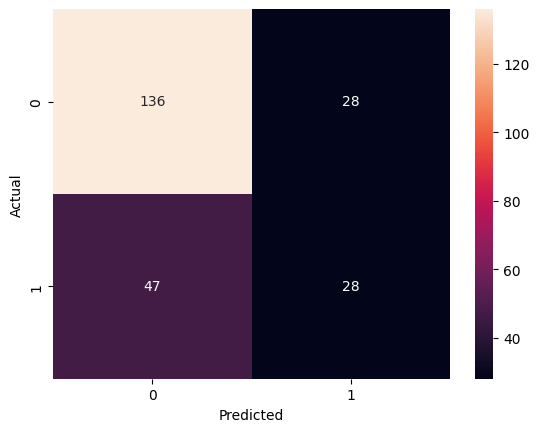

In [33]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(all_labels, all_preds)

plt.figure()
sns.heatmap(cm, annot=True, fmt="d")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [34]:
torch.save(model.state_dict(), "/content/anti_spoof_model_final.pth")